# 02 Covariance and Correlation Spectra

Standalone spectrum/subsampling layer. Inputs are saved normalized covariance and empirical correlation matrices.

In [1]:
from pathlib import Path
import sys

module_dir = Path.cwd()
if not (module_dir / "functional_analysis_utils.py").exists() and (Path.cwd() / "funconn-analysis" / "functional_analysis_utils.py").exists():
    module_dir = Path.cwd() / "funconn-analysis"
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from functional_analysis_utils import (
    RUN_DATE,
    eigenspectrum_desc,
    eigenspectrum_summary,
    fit_power_law_positive,
    functional_paths,
    matrix_abs_limit,
    plot_power_law_fit,
    plot_positive_eigenvalues,
    plot_subsampled_eigenspectrum,
    read_matrix_csv,
    save_eigenspectrum_csv,
    save_matrix,
    sorted_diagonal_spectrum,
)

sns.set_theme(style="white", context="notebook")
paths = functional_paths()
CORR_DIR = paths["correlation"]
EIGEN_DIR = paths["coupling_eigen"]
LAYER_DIR = paths["layer_annotation"]
print("Functional output:", paths["functional_base"])


Functional output: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03


In [2]:
K_FRACTIONS = [0.125, 0.25, 0.5, 0.75]
N_ITER = 50
SEED = 43

normalized_cov_df = read_matrix_csv(CORR_DIR / "V1_col_7_4_activity_normalized_covariance_matrix.csv")
corr_df = read_matrix_csv(CORR_DIR / "V1_col_7_4_activity_correlation_matrix.csv")
normalized_cov_matrix = normalized_cov_df.to_numpy(dtype=float)
corr_matrix = corr_df.to_numpy(dtype=float)

normalized_cov_evals = eigenspectrum_desc(normalized_cov_matrix)
corr_evals = eigenspectrum_desc(corr_matrix)
normalized_cov_diag_ranks, normalized_cov_diag = sorted_diagonal_spectrum(normalized_cov_matrix)
fit_normalized_cov = fit_power_law_positive(normalized_cov_evals, num_top_eigenvalues=100)
fit_corr = fit_power_law_positive(corr_evals, num_top_eigenvalues=100)

print("Normalized covariance Tr(C)/N:", np.trace(normalized_cov_matrix) / normalized_cov_matrix.shape[0])
print("Correlation diagonal min/max:", np.diag(corr_matrix).min(), np.diag(corr_matrix).max())
print("Subsampling k fractions:", K_FRACTIONS)


Normalized covariance Tr(C)/N: 1.0000000000000002
Correlation diagonal min/max: 0.9999999999999998 1.0
Subsampling k fractions: [0.125, 0.25, 0.5, 0.75]


In [3]:
normalized_cov_eigenspectrum_df = save_eigenspectrum_csv(
    normalized_cov_evals,
    EIGEN_DIR / "V1_col_7_4_activity_normalized_covariance_eigenspectrum.csv",
)
normalized_cov_diag_df = pd.DataFrame({
    "rank": np.arange(1, len(normalized_cov_diag) + 1),
    "rank_normalized": normalized_cov_diag_ranks,
    "diagonal_value": normalized_cov_diag,
})
normalized_cov_diag_csv = EIGEN_DIR / "V1_col_7_4_activity_normalized_covariance_diagonal_spectrum.csv"
normalized_cov_diag_df.to_csv(normalized_cov_diag_csv, index=False)
print("Saved:", normalized_cov_diag_csv)

corr_eigenspectrum_df = save_eigenspectrum_csv(
    corr_evals,
    EIGEN_DIR / "V1_col_7_4_activity_correlation_eigenspectrum.csv",
)


Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_activity_normalized_covariance_eigenspectrum.csv
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_activity_normalized_covariance_diagonal_spectrum.csv
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_activity_correlation_eigenspectrum.csv


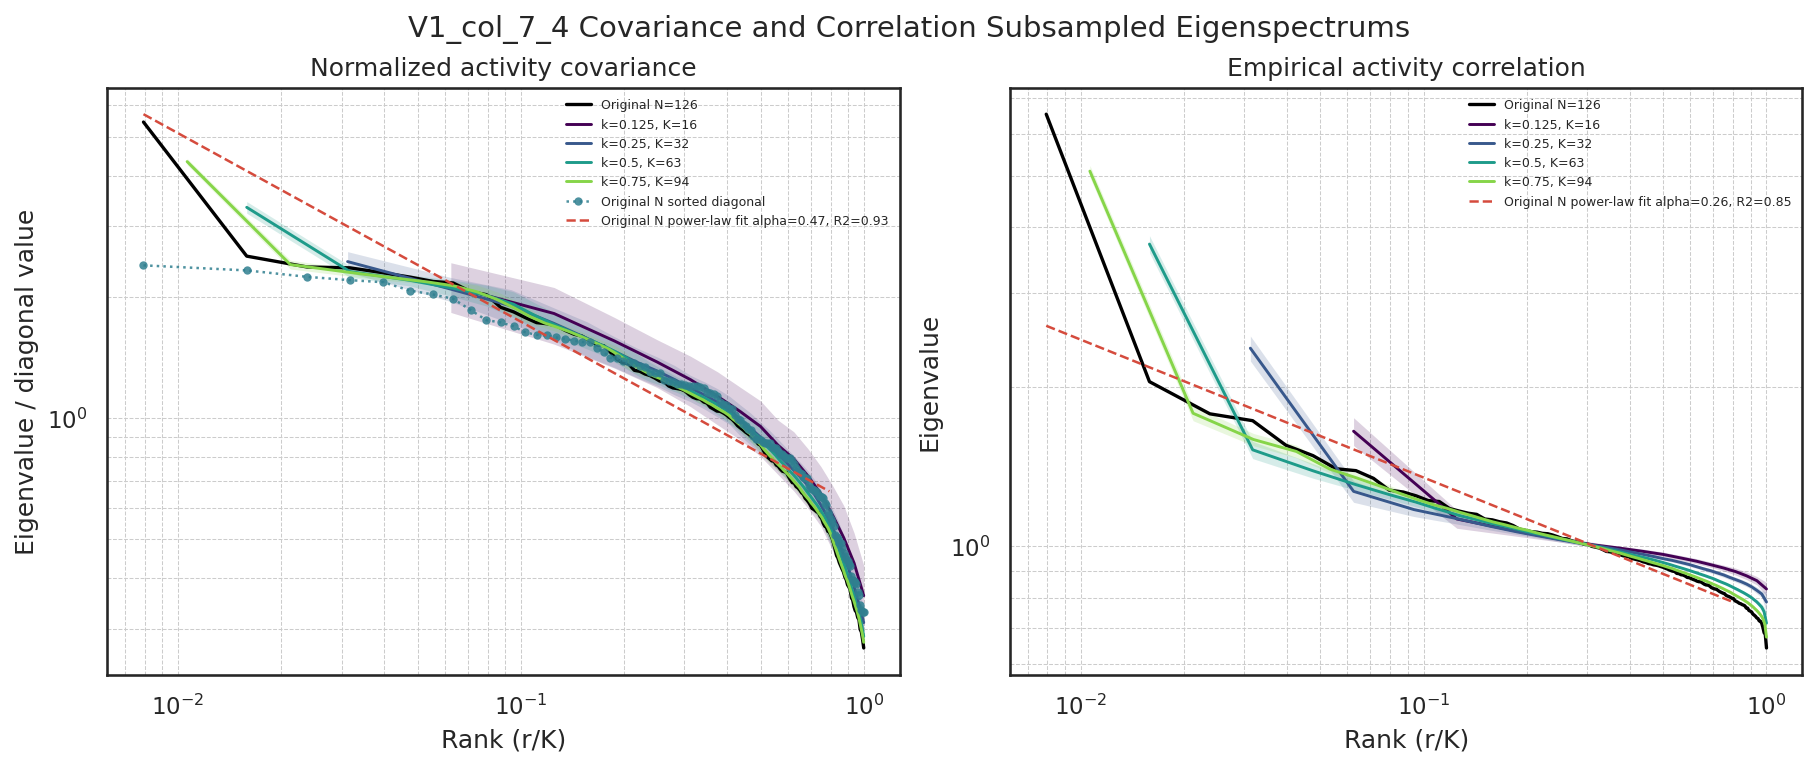

Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_covariance_left_correlation_right_subsampled_eigenspectrums.png
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_activity_normalized_covariance_subsampled_eigenspectrum.csv
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_activity_correlation_subsampled_eigenspectrum.csv
Covariance k values: [0.125, 0.25, 0.5, 0.75]
Correlation k values: [0.125, 0.25, 0.5, 0.75]


,rank,rank_normalized,eigenvalue
0,1,0.007937,5.452633
1,2,0.015873,2.530829
2,3,0.023810,2.378626
3,4,0.031746,2.366914
4,5,0.039683,2.300879
5,6,0.047619,2.244057
6,7,0.055556,2.189084
7,8,0.063492,2.170525
8,9,0.071429,2.065017
9,10,0.079365,2.029961


,rank,rank_normalized,diagonal_value
0,1,0.007937,2.400933
1,2,0.015873,2.332234
2,3,0.023810,2.248135
3,4,0.031746,2.205862
4,5,0.039683,2.179768
5,6,0.047619,2.076506
6,7,0.055556,2.031980
7,8,0.063492,1.982196
8,9,0.071429,1.858757
9,10,0.079365,1.753702


,k_fraction,K,rank,rank_normalized,mean_eigenvalue,std_eigenvalue
0,0.125,16,1,0.0625,2.135159,0.301722
1,0.125,16,2,0.1250,1.822284,0.292843
2,0.125,16,3,0.1875,1.557354,0.224447
3,0.125,16,4,0.2500,1.379977,0.187619
4,0.125,16,5,0.3125,1.248059,0.179066


,rank,rank_normalized,eigenvalue
0,1,0.007937,6.524891
1,2,0.015873,2.043231
2,3,0.023810,1.776919
3,4,0.031746,1.724752
4,5,0.039683,1.550314
5,6,0.047619,1.481808
6,7,0.055556,1.400025
7,8,0.063492,1.388537
8,9,0.071429,1.343001
9,10,0.079365,1.276059


,k_fraction,K,rank,rank_normalized,mean_eigenvalue,std_eigenvalue
0,0.125,16,1,0.0625,1.647862,0.099293
1,0.125,16,2,0.1250,1.125620,0.044399
2,0.125,16,3,0.1875,1.067284,0.023210
3,0.125,16,4,0.2500,1.030646,0.012283
4,0.125,16,5,0.3125,1.006272,0.010568


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150, constrained_layout=True)
fig.suptitle("V1_col_7_4 Covariance and Correlation Subsampled Eigenspectrums", fontsize=14)

normalized_cov_subsampled_df = plot_subsampled_eigenspectrum(
    axes[0],
    normalized_cov_matrix,
    "Normalized activity covariance",
    k_fractions=K_FRACTIONS,
    n_iter=N_ITER,
    seed=SEED + 2000,
)
axes[0].loglog(
    normalized_cov_diag_ranks,
    normalized_cov_diag,
    ":",
    color="#2f7f8f",
    linewidth=1.2,
    marker="o",
    markersize=4,
    alpha=0.85,
    markeredgewidth=0,
    label="Original N sorted diagonal",
)
plot_power_law_fit(axes[0], fit_normalized_cov, "Original N power-law fit", "#d54b3d")
axes[0].set_ylabel("Eigenvalue / diagonal value")
axes[0].legend(frameon=False, fontsize=6)

corr_subsampled_df = plot_subsampled_eigenspectrum(
    axes[1],
    corr_matrix,
    "Empirical activity correlation",
    k_fractions=K_FRACTIONS,
    n_iter=N_ITER,
    seed=SEED,
)
plot_power_law_fit(axes[1], fit_corr, "Original N power-law fit", "#d54b3d")
axes[1].set_ylabel("Eigenvalue")
axes[1].legend(frameon=False, fontsize=6)

png_path = EIGEN_DIR / "V1_col_7_4_covariance_left_correlation_right_subsampled_eigenspectrums.png"
fig.savefig(png_path, bbox_inches="tight")
plt.show()
print("Saved:", png_path)

normalized_cov_subsampled_csv = EIGEN_DIR / "V1_col_7_4_activity_normalized_covariance_subsampled_eigenspectrum.csv"
corr_subsampled_csv = EIGEN_DIR / "V1_col_7_4_activity_correlation_subsampled_eigenspectrum.csv"
normalized_cov_subsampled_df.to_csv(normalized_cov_subsampled_csv, index=False)
corr_subsampled_df.to_csv(corr_subsampled_csv, index=False)
print("Saved:", normalized_cov_subsampled_csv)
print("Saved:", corr_subsampled_csv)

print("Covariance k values:", sorted(normalized_cov_subsampled_df["k_fraction"].unique()))
print("Correlation k values:", sorted(corr_subsampled_df["k_fraction"].unique()))
display(normalized_cov_eigenspectrum_df.head(10))
display(normalized_cov_diag_df.head(10))
display(normalized_cov_subsampled_df.head())
display(corr_eigenspectrum_df.head(10))
display(corr_subsampled_df.head())
